# Dinámica del Entrenamiento: Loss Functions, Optimizers y Regularización

## El paisaje del entrenamiento

Entrenar una red neuronal significa navegar una superficie de Loss de alta dimensión para encontrar parámetros que generalicen bien.

Tres controles gobiernan este proceso:

1. **Loss Function** — *qué* minimizamos (define el objetivo)
2. **Optimizer** — *cómo* actualizamos los Weights (la estrategia de paso)
3. **Regularización** — *restricciones* que evitan memorizar el ruido

Exploraremos cada uno con experimentos ejecutables en un pequeño dataset 2D.

## Dataset de juguete: make_moons

Usamos `make_moons` de scikit-learn — un dataset de 2 clases que **no** es linealmente separable pero suficientemente simple para visualizar.

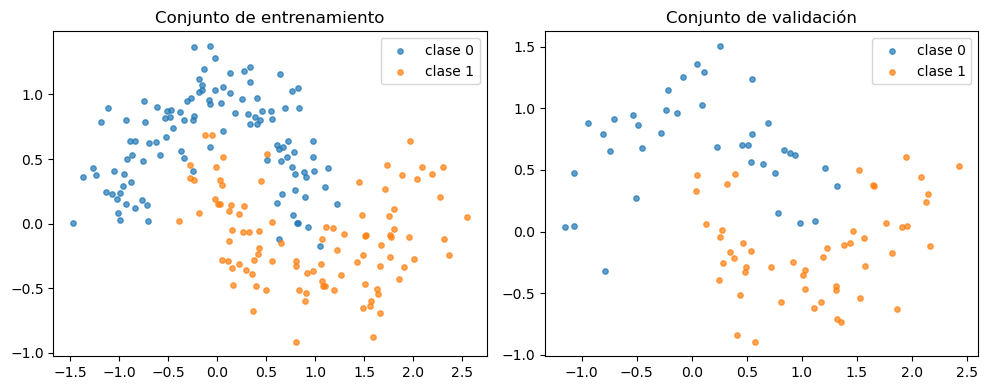

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (Xp, title) in zip(axes, [(X_train, "Conjunto de entrenamiento"), (X_val, "Conjunto de validación")]):
    ax.scatter(Xp[y_train == 0 if "entrenamiento" in title else y_val == 0, 0],
               Xp[y_train == 0 if "entrenamiento" in title else y_val == 0, 1],
               s=15, alpha=0.7, label="clase 0")
    ax.scatter(Xp[y_train == 1 if "entrenamiento" in title else y_val == 1, 0],
               Xp[y_train == 1 if "entrenamiento" in title else y_val == 1, 1],
               s=15, alpha=0.7, label="clase 1")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Loss Functions

La Loss Function cuantifica **qué tan equivocadas** son las predicciones del modelo.

| Tarea | Loss | PyTorch | Notas |
|-------|------|---------|-------|
| Regresión | Mean Squared Error | `nn.MSELoss()` | Penaliza errores grandes cuadráticamente |
| Clasificación binaria | Binary Cross-Entropy | `nn.BCEWithLogitsLoss()` | Espera logits brutos (más estable numéricamente que `nn.BCELoss` + sigmoid) |
| Clasificación multiclase | Cross-Entropy | `nn.CrossEntropyLoss()` | Espera logits brutos, aplica Softmax internamente |

**Regla general:** para clasificación, usa siempre las variantes `WithLogits` / `CrossEntropy` y deja que PyTorch aplique Sigmoid/Softmax internamente — esto evita problemas numéricos con log(0).

### Demo rápida: Loss BCE en make_moons

Entrenamos el mismo modelo pequeño con `BCEWithLogitsLoss` — la elección estándar para problemas binarios.

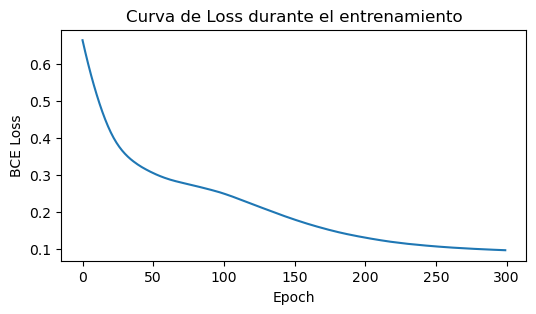

In [2]:
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Curva de Loss durante el entrenamiento")
plt.show()

## Optimizers

Todos los Optimizers siguen la misma idea: **actualizar los Weights en la dirección que reduce la Loss**. Difieren en cómo calculan el paso.

| Optimizer | Intuición | Cuándo usarlo |
|-----------|-----------|---------------|
| `SGD` | "Caminar cuesta abajo" — sigue el gradiente bruto | Línea base, bueno para problemas convexos |
| `SGD + momentum` | "Bola rodando cuesta abajo" — acumula velocidad | Convergencia más rápida, escapa de mínimos locales superficiales |
| `RMSprop` | "Tamaño de paso adaptivo" — escala el LR por parámetro | Bueno para objetivos no estacionarios (p. ej., RNNs) |
| **`Adam`** | Combina momentum + LR adaptivo | **Elección por defecto** para la mayoría de problemas de Deep Learning |

**Recomendación práctica:** empieza con `Adam(lr=1e-3)`. Si necesitas exprimir el último %, cambia a `SGD + momentum` con un schedule de Learning Rate.

> **¿Quieres ver los Optimizers en acción?** Abre ➜ [complementary/tf_playground_guide.ipynb](complementary/tf_playground_guide.ipynb) y experimenta con distintos Learning Rates de forma interactiva.

### Experimento de comparación

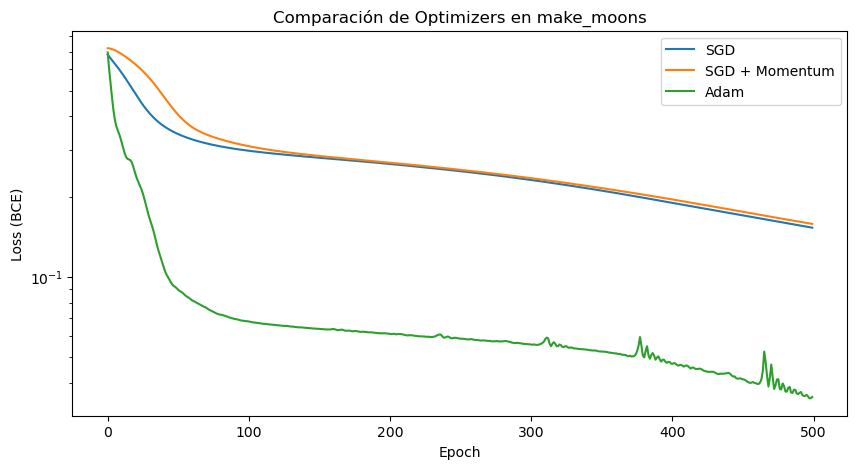

In [3]:
def train_with_optimizer(opt_fn, lr, epochs=500):
    model = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
    optimizer = opt_fn(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

configs = [
    (lambda p, lr: optim.SGD(p, lr=lr), 0.1, "SGD"),
    (lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9), 0.01, "SGD + Momentum"),
    (lambda p, lr: optim.Adam(p, lr=lr), 0.01, "Adam"),
]

plt.figure(figsize=(10, 5))
for opt_fn, lr, name in configs:
    losses = train_with_optimizer(opt_fn, lr)
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.yscale("log")
plt.title("Comparación de Optimizers en make_moons")
plt.legend()
plt.show()

**Qué observar:**
- **SGD** converge lentamente y puede estancarse pronto.
- **SGD + Momentum** acelera el paso por regiones planas.
- **Adam** típicamente alcanza una Loss baja más rápido gracias a los Learning Rates adaptativos.

## Overfitting y regularización

El **Overfitting** ocurre cuando el modelo memoriza los datos de entrenamiento (incluyendo el ruido) en lugar de aprender el patrón subyacente.

**Señal inequívoca:** la Loss de entrenamiento sigue bajando mientras la Loss de validación empieza a **subir**.

Tres defensas comunes:

| Técnica | Cómo funciona | PyTorch |
|---------|--------------|---------|
| **Weight decay (L2)** | Penaliza los Weights grandes — los contrae hacia cero | `Adam(..., weight_decay=1e-4)` |
| **Dropout** | Pone a cero neuronas aleatoriamente durante el entrenamiento — fuerza redundancia | `nn.Dropout(p=0.5)` |
| **Early stopping** | Detiene el entrenamiento cuando la Loss de validación deja de mejorar | Verificación manual en el ciclo de entrenamiento |

### Experimento: línea base vs. regularizado

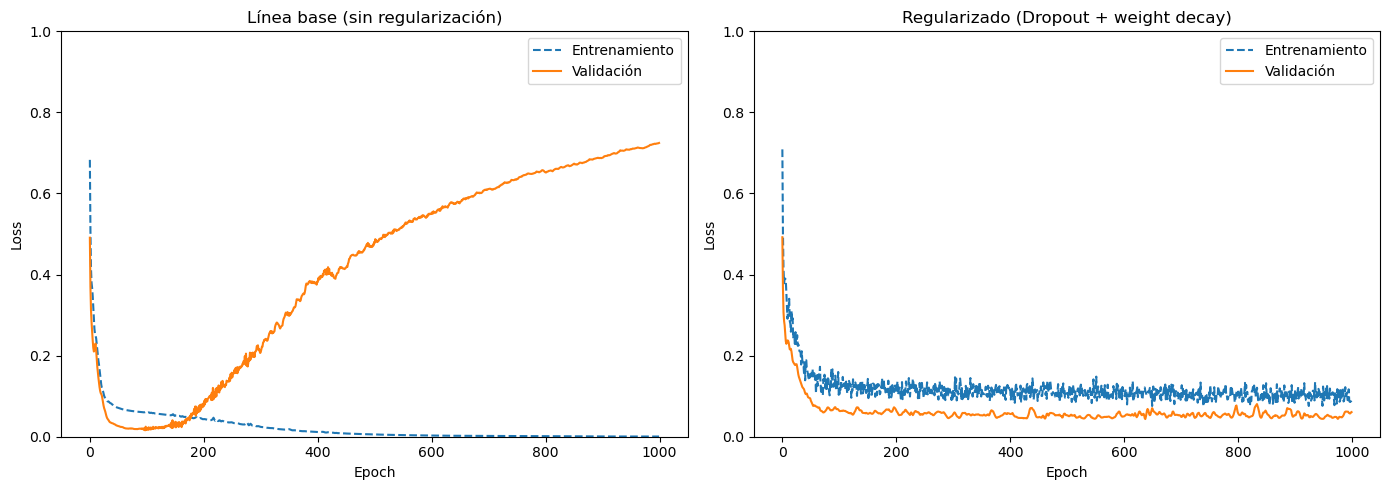

In [4]:
class FlexibleModel(nn.Module):
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

def train_and_record(model, weight_decay: float = 0.0, epochs: int = 1000):
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    train_losses, val_losses = [], []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t)
            val_losses.append(val_loss.item())
    return train_losses, val_losses

# Línea base (sobreparametrizado, sin regularización)
baseline = FlexibleModel(dropout=0.0)
bl_train, bl_val = train_and_record(baseline, weight_decay=0.0)

# Regularizado (Dropout + weight decay)
regularized = FlexibleModel(dropout=0.5)
reg_train, reg_val = train_and_record(regularized, weight_decay=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl, title) in zip(axes, [
    (bl_train, bl_val, "Línea base (sin regularización)"),
    (reg_train, reg_val, "Regularizado (Dropout + weight decay)"),
]):
    ax.plot(tr, label="Entrenamiento", linestyle="--")
    ax.plot(vl, label="Validación")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.legend()
plt.tight_layout()
plt.show()

**Qué observar:**
- **Línea base**: la Loss de validación sube eventualmente aunque la de entrenamiento baja — Overfitting clásico.
- **Regularizado**: la brecha entre entrenamiento y validación es menor, lo que muestra mejor generalización.

## Scheduling del Learning Rate

El Learning Rate (LR) es el hiperparámetro con mayor impacto:
- **Demasiado alto** → la Loss oscila o diverge.
- **Demasiado bajo** → el entrenamiento es dolorosamente lento.

Los **Schedulers** ajustan el LR durante el entrenamiento, típicamente comenzando alto y decayendo con el tiempo.

| Scheduler | Comportamiento | Caso de uso |
|-----------|---------------|-------------|
| `StepLR` | Multiplica el LR por γ cada N Epochs | Simple, confiable |
| `CosineAnnealingLR` | Sigue una curva de coseno hasta casi cero | Decay suave, popular en visión |
| `ReduceLROnPlateau` | Reduce el LR cuando una métrica se estanca | No requiere schedule predefinido |

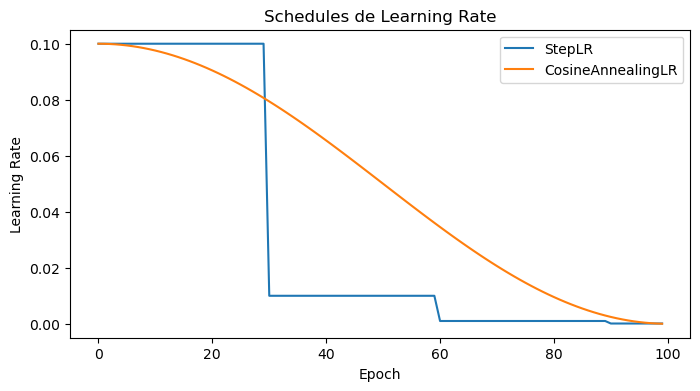

In [5]:
model = nn.Linear(10, 1)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Tres schedulers para comparación
schedulers = {
    "StepLR (step=30, γ=0.1)": optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1),
}

# Reiniciar y recolectar LR para StepLR
lrs_step = []
for epoch in range(100):
    optimizer.step()
    lrs_step.append(optimizer.param_groups[0]["lr"])
    schedulers["StepLR (step=30, γ=0.1)"].step()

# CosineAnnealing
optimizer2 = optim.SGD(model.parameters(), lr=0.1)
sched_cos = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=100)
lrs_cos = []
for epoch in range(100):
    optimizer2.step()
    lrs_cos.append(optimizer2.param_groups[0]["lr"])
    sched_cos.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs_step, label="StepLR")
plt.plot(lrs_cos, label="CosineAnnealingLR")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Schedules de Learning Rate")
plt.legend()
plt.show()

## Resumen

| Componente | Valor por defecto práctico |
|------------|---------------------------|
| **Loss** | `CrossEntropyLoss` (multiclase) o `BCEWithLogitsLoss` (binaria) |
| **Optimizer** | `Adam(lr=1e-3)` — cambia a SGD + momentum para ajuste fino |
| **Regularización** | Dropout (0.2–0.5) en Hidden Layers + weight_decay pequeño |
| **LR schedule** | `ReduceLROnPlateau` para robustez, `CosineAnnealing` para visión |
| **Monitoreo** | Compara siempre Loss de entrenamiento vs. validación para detectar Overfitting |